In [ ]:
%reload_ext autoreload
%autoreload 2
import sys, os
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Add project root to path
project_root = '/sdf/group/neutrino/pgranger/larnd-sim-jax/src'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

%cd /sdf/group/neutrino/pgranger/larnd-sim-jax

from larndsim.consts_jax import build_params_class, load_detector_properties, load_lut
from larndsim.losses_jax import adc2charge
from optimize.strategies import LUTSimulation, LUTProbabilisticSimulation, ProbabilisticLossStrategy
from optimize.dataio import TracksDataset, DataLoader
from optimize.ranges import ranges

print("Setup complete.")

/sdf/home/p/pgranger/.local/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/sdf/group/neutrino/pgranger/larnd-sim-jax
Setup complete.


In [2]:
# --- Configuration ---
INPUT_FILE = '/sdf/data/neutrino/cyifan/diffsim_input/true_through_muon_edep_10cm_vol1cm.h5'
LUT_FILE = 'src/larndsim/detector_properties/response_44_v2a_full_tick.npz'
DET_PROPS = 'src/larndsim/detector_properties/module0.yaml'
PIXEL_LAYOUTS = 'src/larndsim/pixel_layouts/multi_tile_layout-2.4.16_v4.yaml'

RELEVANT_PARAMS = ['Ab', 'kb', 'lifetime', 'tran_diff', 'long_diff', 'eField', 'shift_x', 'shift_y', 'shift_z']

ELECTRON_SAMPLING_RESOLUTION = 0.01
NUMBER_PIX_NEIGHBORS = 4
SIGNAL_LENGTH = 150

# --- Setup Simulation Objects ---
ParamsClass = build_params_class(RELEVANT_PARAMS)
ref_params = load_detector_properties(ParamsClass, DET_PROPS, PIXEL_LAYOUTS)
ref_params = ref_params.replace(
    electron_sampling_resolution=ELECTRON_SAMPLING_RESOLUTION,
    number_pix_neighbors=NUMBER_PIX_NEIGHBORS,
    signal_length=SIGNAL_LENGTH,
    time_window=SIGNAL_LENGTH
)

response, ref_params = load_lut(LUT_FILE, ref_params)
sim_stochastic = LUTSimulation(response)
sim_probabilistic = LUTProbabilisticSimulation(response)
loss_strategy = ProbabilisticLossStrategy(sigma_charge=500.0, eps=1e-8)
# loss_strategy_new = ProbabilisticLossStrategy(sigma_charge=500.0, eps=1e-8, apply_deadtime=True)
loss_strategy_new = ProbabilisticLossStrategy(sigma_charge=500.0, eps=1e-8, first_hit_only=True )

print("Configuration complete.")

INFO:larndsim.consts_jax:Loading response from npz file
Could not load symbol cuFuncGetName. Error: /.singularity.d/libs/libcuda.so.1: undefined symbol: cuFuncGetName


Configuration complete.


In [3]:
# --- Data Loading & Target Preparation ---
dataset = TracksDataset(filename=INPUT_FILE, nevents=-1, max_nbatch=1, max_batch_len=200,
                        electron_sampling_resolution=ELECTRON_SAMPLING_RESOLUTION)
dataloader = DataLoader(dataset, batch_size=1)

track_fields = dataset.get_track_fields()
tracks_batch = dataloader[0].reshape(-1, len(track_fields))
tracks_jax = jnp.array(tracks_batch)

print(f"Loaded {tracks_jax.shape[0]} track segments.")

# Generate stochastic target (discrete hits)
nominal_vals = {p: float(ranges[p]['nom']) for p in RELEVANT_PARAMS}
nom_params = ref_params.replace(**nominal_vals)

target_prediction = sim_stochastic.predict(nom_params, tracks_jax, track_fields, rngkey=42)
target_data = {
    'pixel_id': target_prediction['hit_pixels'],
    'ticks': target_prediction['ticks'],
    'adcs': target_prediction['adcs'],
    'hit_prob': target_prediction['hit_prob']
}

print(f"Generated target with {len(target_data['adcs'])} hits.")

INFO:optimize.dataio:-- The used simulation data includes a total track length of 160.77204704284668 cm.
INFO:optimize.dataio:-- The number of simulation batches is 1.


Loaded 16101 track segments.
Generated target with 688 hits.


In [4]:
# --- 1D Loss Scan Loop ---
PARAM_TO_SCAN = 'kb'
p_range = ranges[PARAM_TO_SCAN]
test_values = np.linspace(p_range['min'], p_range['max'], 100)

scan_results = []
scan_results_new = []

print(f"Scanning {PARAM_TO_SCAN} from {test_values[0]} to {test_values[-1]}...")

for val in tqdm(test_values):
    # Update params
    current_params = nom_params.replace(**{PARAM_TO_SCAN: val})
    
    # Run probabilistic simulation
    prediction = sim_probabilistic.predict(current_params, tracks_jax, track_fields, rngkey=42)
    
    # Compute PPP NLL loss
    loss_val, aux = loss_strategy.compute(current_params, prediction, target_data)
    loss_val_new, aux_new = loss_strategy_new.compute(current_params, prediction, target_data)
    
    scan_results.append({
        'value': val,
        'loss': float(loss_val),
        'll_tick': float(aux['log_likelihood_tick']),
        'll_charge': float(aux['log_likelihood_charge']),
        'no_match': float(aux['no_match_penalty']),
        'expected_hits': float(aux['expected_total_hits']),
        'matched_hits': int(aux['matched_hits'])
    })

    scan_results_new.append({
        'value': val,
        'loss': float(loss_val_new),
        'll_tick': float(aux_new['log_likelihood_tick']),
        'll_charge': float(aux_new['log_likelihood_charge']),
        'no_match': float(aux_new['no_match_penalty']),
        'expected_hits': float(aux_new['expected_total_hits']),
        'matched_hits': int(aux_new['matched_hits'])
    })

print("Scan complete.")

Scanning kb from 0.03 to 0.08...


  0%|          | 0/100 [00:00<?, ?it/s]

Scan complete.


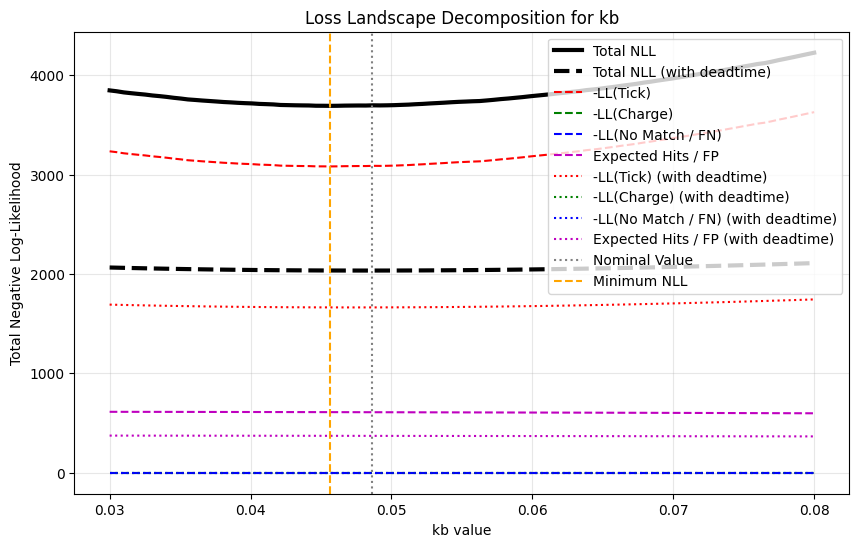

In [5]:
# --- Visualize Loss Landscape ---
vals = [res['value'] for res in scan_results]
total_nll = [res['loss'] for res in scan_results]
ll_tick = [res['ll_tick'] for res in scan_results] # Convert to positive for plotting penalty
ll_charge = [res['ll_charge'] for res in scan_results]
no_match = [res['no_match'] for res in scan_results]
expected_hits = [res['expected_hits'] for res in scan_results]

vals_new = [res['value'] for res in scan_results_new]
total_nll_new = [res['loss'] for res in scan_results_new]
ll_tick_new = [res['ll_tick'] for res in scan_results_new]
ll_charge_new = [res['ll_charge'] for res in scan_results_new]
no_match_new = [res['no_match'] for res in scan_results_new]
expected_hits_new = [res['expected_hits'] for res in scan_results_new]



fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(vals, total_nll, 'k-', lw=3, label='Total NLL')
ax1.plot(vals_new, total_nll_new, 'k--', lw=3, label='Total NLL (with deadtime)')

ax1.set_xlabel(f"{PARAM_TO_SCAN} value")
ax1.set_ylabel("Total Negative Log-Likelihood", color='k')
ax1.grid(True, alpha=0.3)

# ax2 = ax1.twinx()
ax1.plot(vals, ll_tick, 'r--', label='-LL(Tick)')
ax1.plot(vals, ll_charge, 'g--', label='-LL(Charge)')
ax1.plot(vals, no_match, 'b--', label='-LL(No Match / FN)')
ax1.plot(vals, expected_hits, 'm--', label='Expected Hits / FP')
ax1.plot(vals_new, ll_tick_new, 'r:', label='-LL(Tick) (with deadtime)')
ax1.plot(vals_new, ll_charge_new, 'g:', label='-LL(Charge) (with deadtime)')
ax1.plot(vals_new, no_match_new, 'b:', label='-LL(No Match / FN) (with deadtime)')
ax1.plot(vals_new, expected_hits_new, 'm:', label='Expected Hits / FP (with deadtime)')
ax1.axvline(nominal_vals[PARAM_TO_SCAN], color='gray', linestyle=':', label='Nominal Value')

#Plot a line for minimum
min_idx = np.argmin(total_nll)
ax1.axvline(vals[min_idx], color='orange', linestyle='--', label='Minimum NLL')

# ax1.set_ylabel("Component Penalty", color='r')

plt.title(f"Loss Landscape Decomposition for {PARAM_TO_SCAN}")
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.show()

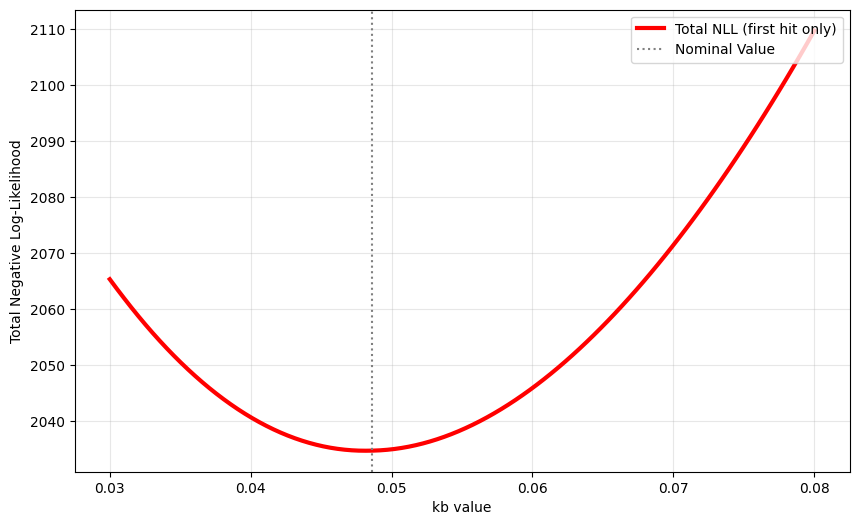

In [8]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# ax1.plot(vals, total_nll, 'k-', lw=3, label='Total NLL')
ax1.plot(vals_new, total_nll_new, 'r-', lw=3, label='Total NLL (first hit only)')

ax1.axvline(nominal_vals[PARAM_TO_SCAN], color='gray', linestyle=':', label='Nominal Value')
ax1.set_xlabel(f"{PARAM_TO_SCAN} value")
ax1.set_ylabel("Total Negative Log-Likelihood", color='k')
ax1.grid(True, alpha=0.3)
ax1.legend(loc="upper right")

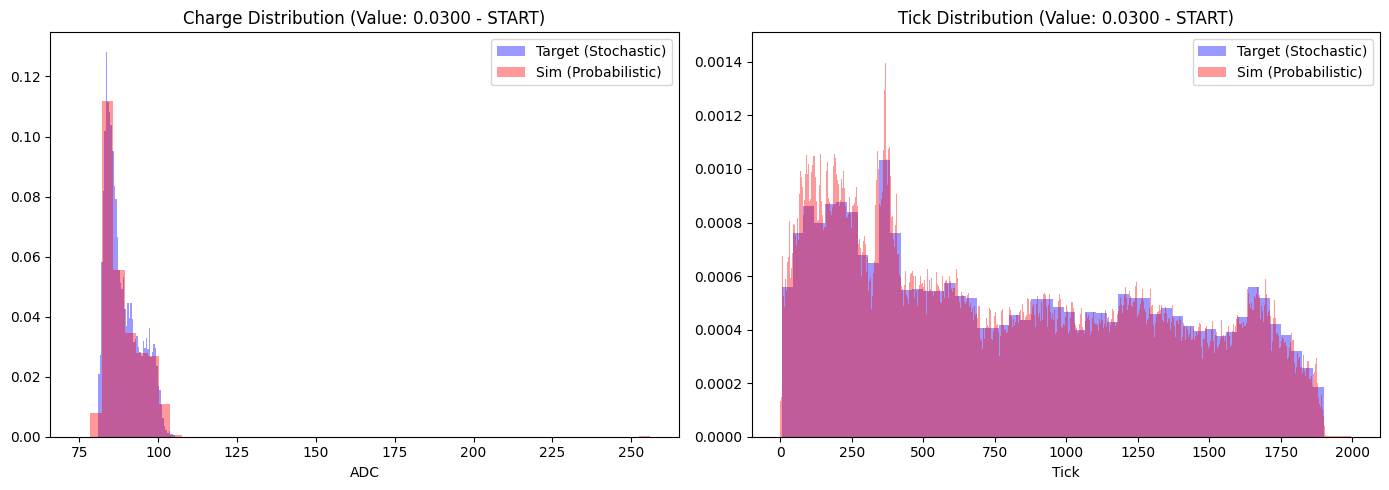

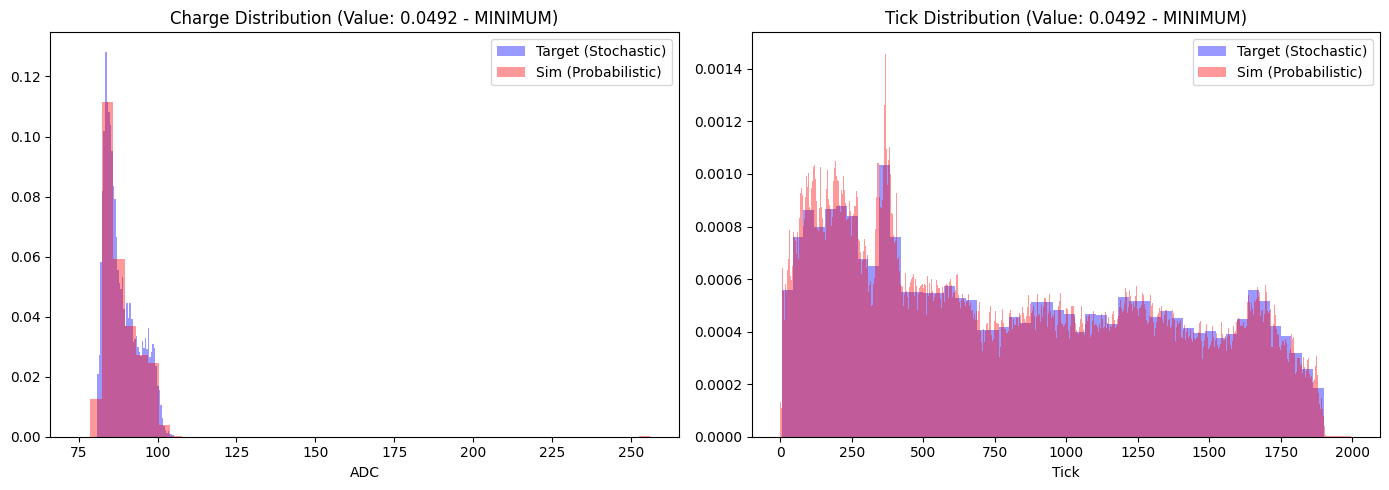

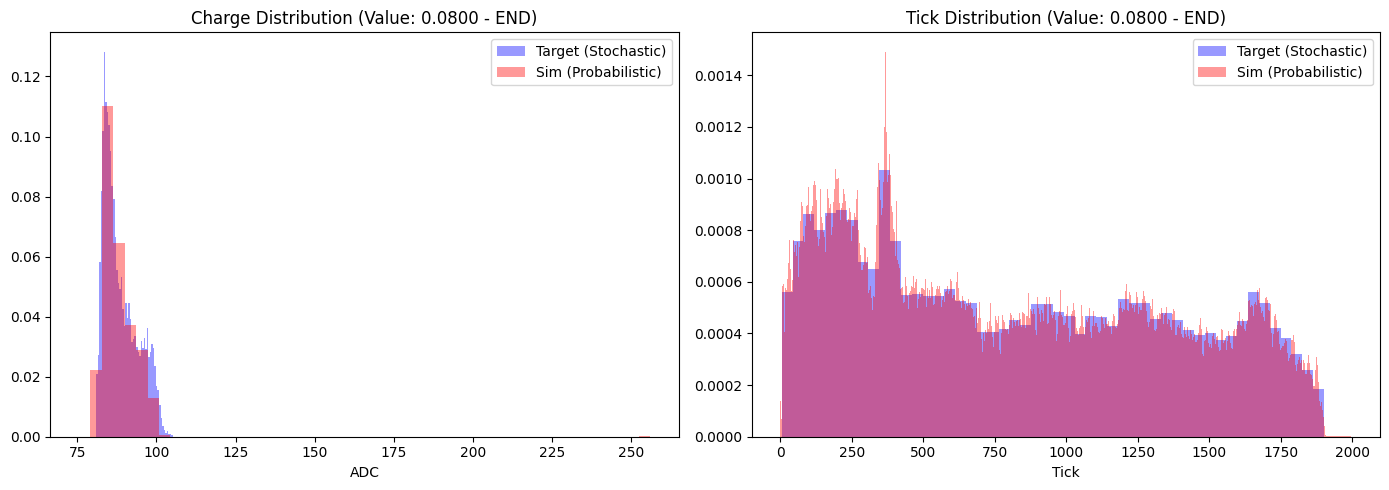

In [11]:
# --- Comparative Distribution Plots ---
def compare_at_value(test_val, title_suffix=""):
    current_params = nom_params.replace(**{PARAM_TO_SCAN: test_val})
    pred = sim_probabilistic.predict(current_params, tracks_jax, track_fields, rngkey=42)
    
    # Extract expected distributions from prediction
    prob = jnp.exp(pred['hit_prob'])
    adcs = pred['adcs_distrib']
    
    # Flatten grid for histograms
    flat_prob = prob.flatten()
    flat_adcs = adcs.flatten()
    
    Npix, Nhits, Nticks = prob.shape
    flat_ticks = jnp.broadcast_to(jnp.arange(Nticks)[None, None, :], prob.shape).flatten()
    
    # Target discrete hits
    target_adcs = target_data['adcs']
    target_ticks = target_data['ticks']
    
    plt.figure(figsize=(14, 5))
    
    # Charge distribution
    plt.subplot(1, 2, 1)
    plt.hist(target_adcs, bins=50, alpha=0.4, label='Target (Stochastic)', color='blue', density=True)
    plt.hist(flat_adcs, weights=flat_prob, bins=50, alpha=0.4, label='Sim (Probabilistic)', color='red', density=True)
    plt.title(f"Charge Distribution {title_suffix}")
    plt.xlabel("ADC")
    plt.legend()
    
    # Time distribution
    plt.subplot(1, 2, 2)
    plt.hist(target_ticks, bins=50, alpha=0.4, label='Target (Stochastic)', color='blue', density=True)
    plt.hist(flat_ticks, weights=flat_prob, bins=Nticks, alpha=0.4, label='Sim (Probabilistic)', color='red', density=True)
    plt.title(f"Tick Distribution {title_suffix}")
    plt.xlabel("Tick")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Compare at Min, Nom, and Max of scan
best_idx = np.argmin(total_nll)
compare_at_value(test_values[0], title_suffix=f"(Value: {test_values[0]:.4f} - START)")
compare_at_value(test_values[best_idx], title_suffix=f"(Value: {test_values[best_idx]:.4f} - MINIMUM)")
compare_at_value(test_values[-1], title_suffix=f"(Value: {test_values[-1]:.4f} - END)")

Pixels with predicted ADC > 110 (prob_above > 0.01):
  Total predicted pixels : 512
  Concerned pixels       : 1


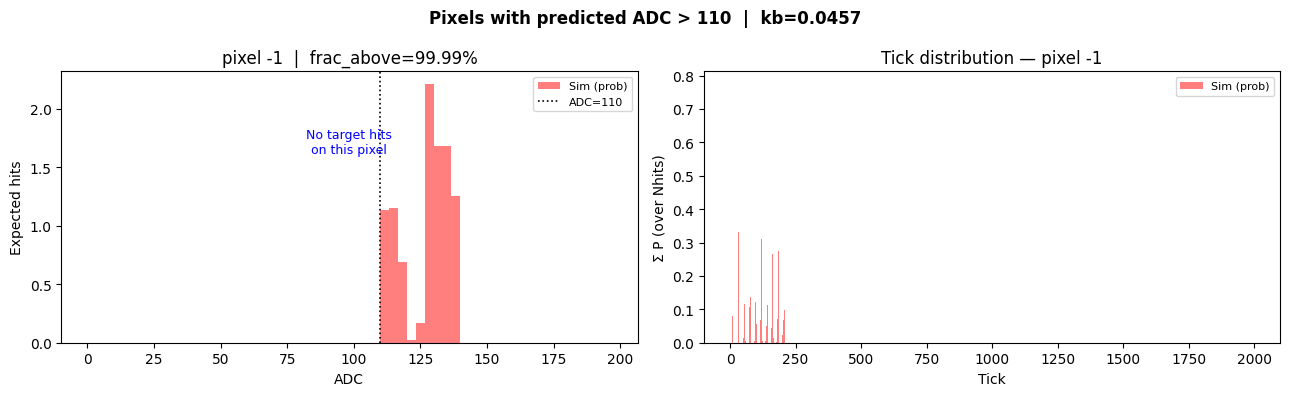


Top-1 concerned pixels (sorted by predicted mass above 110 ADC):
    pixel_id  prob_above  frac_above  n_tgt_hits
          -1      10.000      99.99%           0


In [18]:

# --- Deep-dive: pixels with predicted ADC > 110 but no such target hits ---
ADC_THRESHOLD = 110.0
INSPECT_VAL = test_values[best_idx]  # use the minimum-NLL value; change as needed

current_params_inspect = nom_params.replace(**{PARAM_TO_SCAN: INSPECT_VAL})
pred_inspect = sim_probabilistic.predict(current_params_inspect, tracks_jax, track_fields, rngkey=42)

prob_3d  = jnp.exp(pred_inspect['hit_prob'])   # (Npix, Nhits, Nticks)
adcs_3d  = pred_inspect['adcs_distrib']         # (Npix, Nhits, Nticks)
pred_pixels = pred_inspect['unique_pixels']      # (Npix,)

Npix, Nhits, Nticks = prob_3d.shape

# --- Find pixels where predicted mass is concentrated above the threshold --------
# Weighted fraction of probability above ADC_THRESHOLD per pixel
prob_above = np.array(jnp.sum(jnp.where(adcs_3d > ADC_THRESHOLD, prob_3d, 0.0), axis=(1, 2)))
prob_total = np.array(jnp.sum(prob_3d, axis=(1, 2)))
frac_above = np.where(prob_total > 0, prob_above / prob_total, 0.0)

# Pixels that exceed the threshold: sort by weighted mass above threshold
concerned_mask = prob_above > 0.01   # at least 1% of a hit expected above threshold
concerned_pix_indices = np.argsort(prob_above)[::-1]
concerned_pix_indices = concerned_pix_indices[concerned_mask[concerned_pix_indices]]

print(f"Pixels with predicted ADC > {ADC_THRESHOLD:.0f} (prob_above > 0.01):")
print(f"  Total predicted pixels : {Npix}")
print(f"  Concerned pixels       : {len(concerned_pix_indices)}")

# --- For each concerned pixel, check if target has hits above threshold ----------
target_pix = np.array(target_data['pixel_id'])
target_adc = np.array(target_data['adcs'])
pred_pix_np = np.array(pred_pixels)

MAX_SHOW = min(6, len(concerned_pix_indices))
ncols = 2
nrows = MAX_SHOW
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 4 * nrows))
if nrows == 1:
    axes = axes[np.newaxis, :]

fig.suptitle(
    f"Pixels with predicted ADC > {ADC_THRESHOLD:.0f}  |  {PARAM_TO_SCAN}={INSPECT_VAL:.4f}",
    fontsize=12, fontweight='bold'
)

for row, pix_idx in enumerate(concerned_pix_indices[:MAX_SHOW]):
    pixel_id = int(pred_pix_np[pix_idx])

    # ── Predicted 2-D distribution: marginalise over Nhits dim ──────────────────
    # Collapse Nhits → weighted ADC distribution per tick, then sum over ticks
    p_pix  = np.array(prob_3d[pix_idx])    # (Nhits, Nticks)
    a_pix  = np.array(adcs_3d[pix_idx])    # (Nhits, Nticks)

    # ADC marginal: flat (Nhits*Nticks) weighted histogram
    p_flat = p_pix.flatten()
    a_flat = a_pix.flatten()
    
    # Tick marginal: sum prob over Nhits
    tick_prob = np.sum(p_pix, axis=0)      # (Nticks,)

    # Target hits on this pixel
    tgt_mask  = target_pix == pixel_id
    tgt_adcs  = target_adc[tgt_mask]
    tgt_ticks = np.array(target_data['ticks'])[tgt_mask]

    # ── Left: ADC distribution ────────────────────────────────────────────────
    ax = axes[row, 0]
    adc_bins = np.linspace(0, max(a_flat.max(), tgt_adcs.max() if len(tgt_adcs) > 0 else 1, ADC_THRESHOLD * 1.1), 60)
    ax.hist(a_flat, weights=p_flat, bins=adc_bins, alpha=0.5, color='red',
            label='Sim (prob)', density=False)
    if len(tgt_adcs) > 0:
        ax.hist(tgt_adcs, bins=adc_bins, alpha=0.5, color='blue',
                label=f'Target ({len(tgt_adcs)} hits)', density=False)
    else:
        ax.text(0.5, 0.7, 'No target hits\non this pixel',
                transform=ax.transAxes, ha='center', color='blue', fontsize=9)
    ax.axvline(ADC_THRESHOLD, color='k', ls=':', lw=1.2, label=f'ADC={ADC_THRESHOLD:.0f}')
    ax.set_xlabel('ADC')
    ax.set_ylabel('Expected hits')
    ax.set_title(f'pixel {pixel_id}  |  frac_above={frac_above[pix_idx]:.2%}')
    ax.legend(fontsize=8)

    # ── Right: tick distribution ──────────────────────────────────────────────
    ax = axes[row, 1]
    tick_bins = np.arange(Nticks + 1) - 0.5
    ax.bar(np.arange(Nticks), tick_prob, alpha=0.5, color='red', label='Sim (prob)')
    if len(tgt_ticks) > 0:
        ax.hist(tgt_ticks, bins=tick_bins, alpha=0.5, color='blue',
                label=f'Target ({len(tgt_ticks)} ticks)')
    ax.set_xlabel('Tick')
    ax.set_ylabel('Σ P (over Nhits)')
    ax.set_title(f'Tick distribution — pixel {pixel_id}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# --- Summary table ---------------------------------------------------------------
print(f"\nTop-{MAX_SHOW} concerned pixels (sorted by predicted mass above {ADC_THRESHOLD:.0f} ADC):")
print(f"{'pixel_id':>12}  {'prob_above':>10}  {'frac_above':>10}  {'n_tgt_hits':>10}")
for pix_idx in concerned_pix_indices[:MAX_SHOW]:
    pixel_id = int(pred_pix_np[pix_idx])
    n_tgt = int(np.sum(target_pix == pixel_id))
    print(f"{pixel_id:>12}  {prob_above[pix_idx]:>10.3f}  {frac_above[pix_idx]:>10.2%}  {n_tgt:>10}")


In [15]:

# --- Per-pixel NLL discrepancy at the nominal (target) parameter value ---
# Metric: per-pixel sum of (tick NLL + charge NLL) contributions
# Only matched pixels contribute; unmatched target pixels get the floor penalty.

import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.colors as pc
from optimize.strategies import compute_occurrence_indices

loss_strategy = loss_strategy_new

DISCREPANCY_VAL = nominal_vals[PARAM_TO_SCAN]   # nominal = "target" value
MAX_SHOW_DISC   = 6                              # how many worst pixels to plot

disc_params = nom_params.replace(**{PARAM_TO_SCAN: DISCREPANCY_VAL})
disc_pred   = sim_probabilistic.predict(disc_params, tracks_jax, track_fields, rngkey=42)

prob_3d_d   = jnp.exp(disc_pred['hit_prob'])    # (Npix, Nhits, Nticks)
logp_3d_d   = disc_pred['hit_prob']             # (Npix, Nhits, Nticks) — log P(tick|pixel)
adcs_3d_d   = disc_pred['adcs_distrib']          # (Npix, Nhits, Nticks)
pred_pix_d  = np.array(disc_pred['unique_pixels'])

d_pixels    = np.array(target_data['pixel_id'])
d_ticks     = np.array(target_data['ticks']).astype(int)
d_adcs      = np.array(target_data['adcs'])

log_eps_d   = float(jnp.log(loss_strategy.eps))
sig_ke_d    = loss_strategy.sigma_charge / 1000.0

# Match target hits → predicted pixel index
pidx_d = np.array(jnp.searchsorted(jnp.array(pred_pix_d), jnp.array(d_pixels)))
pidx_d = np.clip(pidx_d, 0, len(pred_pix_d) - 1)
match_d = (pred_pix_d[pidx_d] == d_pixels) & (d_pixels >= 0)
trig_d  = np.array(compute_occurrence_indices(jnp.array(d_pixels)))

# Per-hit tick NLL (floored)
raw_tick_logp = np.array(logp_3d_d)[pidx_d, trig_d, d_ticks]
tick_logp_d   = np.maximum(raw_tick_logp, log_eps_d)
tick_nll_d    = -tick_logp_d

# Per-hit charge NLL
t_chg_d = np.array(adc2charge(jnp.array(d_adcs), disc_params))
p_chg_d = np.array(adc2charge(adcs_3d_d[pidx_d, trig_d, d_ticks], disc_params))
chg_nll_d = 0.5 * ((t_chg_d - p_chg_d) / sig_ke_d) ** 2

# Combined NLL per hit
total_nll_per_hit = np.where(match_d, tick_nll_d + chg_nll_d, -log_eps_d)

# Aggregate per unique target pixel
unique_tgt_pixels = np.unique(d_pixels[d_pixels >= 0])
pix_nll   = {}
pix_nhits = {}
for px in unique_tgt_pixels:
    mask_px = d_pixels == px
    pix_nll[px]   = float(np.sum(total_nll_per_hit[mask_px]))
    pix_nhits[px] = int(np.sum(mask_px))

sorted_pix   = sorted(pix_nll, key=pix_nll.get, reverse=True)
worst_pixels = sorted_pix[:MAX_SHOW_DISC]

print(f"Per-pixel NLL discrepancy at nominal {PARAM_TO_SCAN}={DISCREPANCY_VAL:.4f}")
print(f"{'pixel_id':>12}  {'nll_sum':>10}  {'n_hits':>8}  {'nll/hit':>10}")
for px in worst_pixels:
    nh = pix_nhits[px]
    print(f"{px:>12}  {pix_nll[px]:>10.2f}  {nh:>8}  {pix_nll[px]/max(nh,1):>10.2f}")

# ── Plotly interactive figures ────────────────────────────────────────────────────
Npix_d, Nhits_d, Nticks_d = prob_3d_d.shape
tick_axis = np.arange(Nticks_d)

# Colour scale for per-trigger curves
trig_colors = pc.sample_colorscale('plasma', [i / max(Nhits_d - 1, 1) for i in range(Nhits_d)])

for pixel_id in worst_pixels:
    pix_pred_idx = np.searchsorted(pred_pix_d, pixel_id)
    has_pred = (pix_pred_idx < len(pred_pix_d)) and (pred_pix_d[pix_pred_idx] == pixel_id)

    tgt_mask     = d_pixels == pixel_id
    tgt_adcs_px  = d_adcs[tgt_mask]
    tgt_ticks_px = d_ticks[tgt_mask]

    nll_ph  = pix_nll[pixel_id] / max(pix_nhits[pixel_id], 1)
    fig_title = (f"pixel {pixel_id}  |  NLL={pix_nll[pixel_id]:.1f}  ({nll_ph:.1f}/hit)"
                 f"  —  {PARAM_TO_SCAN}={DISCREPANCY_VAL:.4f}")

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("ADC distribution", "Tick probability  P(tick | pixel)"),
        horizontal_spacing=0.1
    )

    # ── Left: ADC ─────────────────────────────────────────────────────────────
    if has_pred:
        p_pix  = np.array(prob_3d_d[pix_pred_idx])
        lp_pix = np.array(logp_3d_d[pix_pred_idx])
        a_pix  = np.array(adcs_3d_d[pix_pred_idx])
        p_flat = p_pix.flatten()
        a_flat = a_pix.flatten()
        adc_max = max(a_flat.max(), tgt_adcs_px.max() if len(tgt_adcs_px) > 0 else 1)
        adc_bins = np.linspace(0, adc_max * 1.05, 61)
        sim_counts, _ = np.histogram(a_flat, bins=adc_bins, weights=p_flat)
        fig.add_trace(go.Bar(
            x=0.5 * (adc_bins[:-1] + adc_bins[1:]), y=sim_counts,
            name='Sim (prob)', marker_color='rgba(220,50,50,0.5)',
            width=adc_bins[1] - adc_bins[0], showlegend=True
        ), row=1, col=1)
    else:
        adc_bins = np.linspace(0, tgt_adcs_px.max() * 1.05 if len(tgt_adcs_px) > 0 else 120, 61)
        fig.add_annotation(text="Pixel not in predicted set", xref="x domain", yref="y domain",
                           x=0.5, y=0.6, showarrow=False, row=1, col=1)

    if len(tgt_adcs_px) > 0:
        tgt_counts, _ = np.histogram(tgt_adcs_px, bins=adc_bins)
        fig.add_trace(go.Bar(
            x=0.5 * (adc_bins[:-1] + adc_bins[1:]), y=tgt_counts,
            name=f'Target ({len(tgt_adcs_px)} hits)', marker_color='rgba(50,100,220,0.5)',
            width=adc_bins[1] - adc_bins[0], showlegend=True
        ), row=1, col=1)

    # ── Right: Tick probability ────────────────────────────────────────────────
    if has_pred:
        tick_probs_raw = np.exp(lp_pix)                          # (Nhits, Nticks)
        norm_factor    = tick_probs_raw.sum(axis=1, keepdims=True)
        norm_factor    = np.where(norm_factor > 0, norm_factor, 1.0)
        tick_probs_norm = tick_probs_raw / norm_factor

        for nhit_i in range(Nhits_d):
            if tick_probs_norm[nhit_i].max() < 1e-4:
                continue
            fig.add_trace(go.Scatter(
                x=tick_axis, y=tick_probs_norm[nhit_i],
                mode='lines', name=f'trig {nhit_i}',
                line=dict(color=trig_colors[nhit_i], width=1),
                opacity=0.7, showlegend=True
            ), row=1, col=2)

        # Marginal
        weights = p_pix.sum(axis=1)
        if weights.sum() > 0:
            marginal = (tick_probs_norm * weights[:, None]).sum(axis=0) / weights.sum()
            fig.add_trace(go.Scatter(
                x=tick_axis, y=marginal,
                mode='lines', name='Marginal P(tick)',
                line=dict(color='black', width=2.5, dash='dash'),
                showlegend=True
            ), row=1, col=2)

    if len(tgt_ticks_px) > 0:
        tick_bins = np.arange(Nticks_d + 1) - 0.5
        tgt_tcounts, _ = np.histogram(tgt_ticks_px, bins=tick_bins, density=True)
        fig.add_trace(go.Bar(
            x=tick_axis, y=tgt_tcounts,
            name=f'Target ({len(tgt_ticks_px)} ticks)',
            marker_color='rgba(50,100,220,0.35)',
            width=1.0, showlegend=True
        ), row=1, col=2)
        # Rug
        fig.add_trace(go.Scatter(
            x=tgt_ticks_px, y=np.zeros(len(tgt_ticks_px)),
            mode='markers', name='Target ticks (rug)',
            marker=dict(symbol='line-ns', size=10, color='blue',
                        line=dict(width=1.5, color='blue')),
            showlegend=True
        ), row=1, col=2)

    fig.update_layout(
        title=fig_title, barmode='overlay',
        height=420, width=1050,
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
        template='plotly_white'
    )
    fig.update_xaxes(title_text='ADC', row=1, col=1)
    fig.update_xaxes(title_text='Tick', row=1, col=2)
    fig.update_yaxes(title_text='Expected hits', row=1, col=1)
    fig.update_yaxes(title_text='P(tick | pixel)', row=1, col=2)
    fig.show()


Per-pixel NLL discrepancy at nominal kb=0.0486
    pixel_id     nll_sum    n_hits     nll/hit
      223936       61.87         5       12.37
      185564       60.36         5       12.07
      204246       43.59         3       14.53
     1142532       41.39         3       13.80
     1142397       39.91         3       13.30
     1142528       37.58         3       12.53


In [23]:

# --- Monte-Carlo FEE noise ensemble vs probabilistic distributions ---------------
#
# Strategy:
#   1. Run simulate_wfs() ONCE (deterministic physics, no noise).
#   2. Call simulate_stochastic() N_SEEDS times with different seeds.
#   3. For the worst discrepancy pixels, compare the empirical (ADC, tick)
#      distributions from all seeds against the probabilistic prediction.

from larndsim.sim_jax import simulate_wfs, simulate_stochastic
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.colors as pc

N_SEEDS      = 200    # number of FEE noise realisations (raise to 1000 if fast enough)
MC_PARAMS    = disc_params   # use the same params as the discrepancy cell
WORST_PIX    = worst_pixels  # from previous cell

print(f"Running {N_SEEDS} FEE noise realisations at {PARAM_TO_SCAN}={DISCREPANCY_VAL:.4f} ...")

# ── Step 1: compute waveforms once ───────────────────────────────────────────────
response_arr = response   # the LUT response array loaded in cell 2
wfs_mc, unique_pixels_mc = simulate_wfs(MC_PARAMS, response_arr, tracks_jax, track_fields)
unique_pixels_mc_np = np.array(unique_pixels_mc)

# ── Step 2: loop over seeds ───────────────────────────────────────────────────────
# Accumulate per-pixel hit lists: {pixel_id: {'adcs': [...], 'ticks': [...]}}
from collections import defaultdict
mc_hits = defaultdict(lambda: {'adcs': [], 'ticks': []})

for seed in tqdm(range(N_SEEDS)):
    adcs_s, _, _, _, ticks_s, _, _, hit_pixels_s = simulate_stochastic(
        MC_PARAMS, wfs_mc, unique_pixels_mc, rngseed=seed
    )
    hp = np.array(hit_pixels_s)
    ad = np.array(adcs_s)
    tk = np.array(ticks_s).astype(int)
    for px in WORST_PIX:
        mask = hp == px
        if mask.any():
            mc_hits[px]['adcs'].extend(ad[mask].tolist())
            mc_hits[px]['ticks'].extend(tk[mask].tolist())

print("Done.")
for px in WORST_PIX:
    n = len(mc_hits[px]['adcs'])
    print(f"  pixel {px}: {n} hits across {N_SEEDS} seeds  ({n/N_SEEDS:.2f} hits/seed)")

# ── Step 3: compare per pixel ─────────────────────────────────────────────────────
Npix_d, Nhits_d, Nticks_d = prob_3d_d.shape
tick_axis = np.arange(Nticks_d)
trig_colors_mc = pc.sample_colorscale('plasma', [i / max(Nhits_d - 1, 1) for i in range(Nhits_d)])

for pixel_id in WORST_PIX:
    pix_pred_idx = np.searchsorted(pred_pix_d, pixel_id)
    has_pred = (pix_pred_idx < len(pred_pix_d)) and (pred_pix_d[pix_pred_idx] == pixel_id)

    mc_adcs_px  = np.array(mc_hits[pixel_id]['adcs'])
    mc_ticks_px = np.array(mc_hits[pixel_id]['ticks'])

    # Single-seed target hits (for reference)
    tgt_mask_px    = d_pixels == pixel_id
    tgt_adcs_px    = d_adcs[tgt_mask_px]
    tgt_ticks_px   = d_ticks[tgt_mask_px]

    nll_ph    = pix_nll[pixel_id] / max(pix_nhits[pixel_id], 1)
    fig_title = (f"pixel {pixel_id}  |  NLL={pix_nll[pixel_id]:.1f}  ({nll_ph:.1f}/hit)"
                 f"  —  {N_SEEDS} FEE seeds vs Probabilistic")

    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=(f"ADC distribution  (MC n={len(mc_adcs_px)})",
                        f"Tick distribution  (MC n={len(mc_ticks_px)})"),
        horizontal_spacing=0.10
    )

    # ── ADC panel ─────────────────────────────────────────────────────────────
    if has_pred:
        p_pix  = np.array(prob_3d_d[pix_pred_idx])
        lp_pix = np.array(logp_3d_d[pix_pred_idx])
        a_pix  = np.array(adcs_3d_d[pix_pred_idx])
        p_flat = p_pix.flatten()
        a_flat = a_pix.flatten()
        adc_max  = max(a_flat.max(),
                       mc_adcs_px.max() if len(mc_adcs_px) > 0 else 1,
                       tgt_adcs_px.max() if len(tgt_adcs_px) > 0 else 1)
        adc_bins = np.linspace(0, adc_max * 1.05, 61)
        # Probabilistic prediction (normalised to per-seed rate)
        sim_counts, _ = np.histogram(a_flat, bins=adc_bins, weights=p_flat)
        fig.add_trace(go.Bar(
            x=0.5 * (adc_bins[:-1] + adc_bins[1:]), y=sim_counts,
            name='Probabilistic sim', marker_color='rgba(220,50,50,0.5)',
            width=adc_bins[1] - adc_bins[0]
        ), row=1, col=1)
    else:
        adc_bins = np.linspace(0, max(
            mc_adcs_px.max() if len(mc_adcs_px) > 0 else 1,
            tgt_adcs_px.max() if len(tgt_adcs_px) > 0 else 120
        ) * 1.05, 61)

    if len(mc_adcs_px) > 0:
        # MC histogram normalised to per-seed rate (divide by N_SEEDS)
        mc_counts, _ = np.histogram(mc_adcs_px, bins=adc_bins)
        fig.add_trace(go.Bar(
            x=0.5 * (adc_bins[:-1] + adc_bins[1:]), y=mc_counts / N_SEEDS,
            name=f'MC FEE ({N_SEEDS} seeds)', marker_color='rgba(50,180,50,0.5)',
            width=adc_bins[1] - adc_bins[0]
        ), row=1, col=1)

    if len(tgt_adcs_px) > 0:
        tgt_counts, _ = np.histogram(tgt_adcs_px, bins=adc_bins)
        fig.add_trace(go.Bar(
            x=0.5 * (adc_bins[:-1] + adc_bins[1:]), y=tgt_counts.astype(float),
            name=f'Target seed 42 ({len(tgt_adcs_px)} hits)',
            marker_color='rgba(50,100,220,0.5)',
            width=adc_bins[1] - adc_bins[0]
        ), row=1, col=1)

    # ── Tick panel ────────────────────────────────────────────────────────────
    tick_bins = np.arange(Nticks_d + 1) - 0.5

    if has_pred:
        tick_probs_raw  = np.exp(lp_pix)
        norm_factor     = tick_probs_raw.sum(axis=1, keepdims=True)
        norm_factor     = np.where(norm_factor > 0, norm_factor, 1.0)
        tick_probs_norm = tick_probs_raw / norm_factor         # (Nhits, Nticks)

        # Marginal
        weights = p_pix.sum(axis=1)
        if weights.sum() > 0:
            marginal = (tick_probs_norm * weights[:, None]).sum(axis=0) / weights.sum()
            fig.add_trace(go.Scatter(
                x=tick_axis, y=marginal,
                mode='lines', name='Probabilistic marginal P(tick)',
                line=dict(color='red', width=2.5, dash='dash')
            ), row=1, col=2)

        # Individual trigger curves
        for nhit_i in range(Nhits_d):
            if tick_probs_norm[nhit_i].max() < 1e-4:
                continue
            fig.add_trace(go.Scatter(
                x=tick_axis, y=tick_probs_norm[nhit_i],
                mode='lines', name=f'Prob trig {nhit_i}',
                line=dict(color=trig_colors_mc[nhit_i], width=1),
                opacity=0.5, showlegend=False
            ), row=1, col=2)

    if len(mc_ticks_px) > 0:
        mc_tcounts, _ = np.histogram(mc_ticks_px, bins=tick_bins)
        # normalise to probability (density-like, sum=1)
        mc_tprob = mc_tcounts / mc_tcounts.sum() if mc_tcounts.sum() > 0 else mc_tcounts
        fig.add_trace(go.Bar(
            x=tick_axis, y=mc_tprob,
            name=f'MC FEE ticks ({N_SEEDS} seeds)',
            marker_color='rgba(50,180,50,0.4)', width=1.0
        ), row=1, col=2)

    if len(tgt_ticks_px) > 0:
        tgt_tcounts, _ = np.histogram(tgt_ticks_px, bins=tick_bins, density=True)
        fig.add_trace(go.Bar(
            x=tick_axis, y=tgt_tcounts,
            name=f'Target seed 42 ({len(tgt_ticks_px)} ticks)',
            marker_color='rgba(50,100,220,0.35)', width=1.0
        ), row=1, col=2)
        fig.add_trace(go.Scatter(
            x=tgt_ticks_px, y=np.zeros(len(tgt_ticks_px)),
            mode='markers', name='Target ticks (rug)',
            marker=dict(symbol='line-ns', size=10, color='blue',
                        line=dict(width=1.5, color='blue')),
            showlegend=True
        ), row=1, col=2)

    fig.update_layout(
        title=fig_title, barmode='overlay',
        height=440, width=1100,
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
        template='plotly_white'
    )
    fig.update_xaxes(title_text='ADC', row=1, col=1)
    fig.update_xaxes(title_text='Tick', row=1, col=2)
    fig.update_yaxes(title_text='Expected hits / seed', row=1, col=1)
    fig.update_yaxes(title_text='P(tick)', row=1, col=2)
    fig.show()


Running 200 FEE noise realisations at kb=0.0486 ...


  0%|          | 0/200 [00:00<?, ?it/s]

Done.
  pixel 79271: 395 hits across 200 seeds  (1.98 hits/seed)
  pixel 80382: 231 hits across 200 seeds  (1.16 hits/seed)
  pixel 146196: 392 hits across 200 seeds  (1.96 hits/seed)
  pixel 80798: 360 hits across 200 seeds  (1.80 hits/seed)
  pixel 66932: 400 hits across 200 seeds  (2.00 hits/seed)
  pixel 64148: 585 hits across 200 seeds  (2.92 hits/seed)


In [13]:

# --- Scan comparing different (time_window, sigma_time) hyperparameter settings ---
#
# time_window : number of ticks (+/-) around the observed tick to average over
# sigma_time  : Gaussian kernel width (ticks) for that averaging window
#
# Sensible sweep:
#   (0, 1.0)  – point-wise (no averaging, current baseline if time_window>0 was not set)
#   (1, 0.5)  – very narrow 1-tick window
#   (2, 1.0)  – default
#   (2, 2.0)  – default window, softer kernel
#   (5, 2.0)  – wide window, soft kernel
#   (5, 0.5)  – wide window, sharp kernel (plateau-like)

import plotly.graph_objects as go
import plotly.colors as pc

PARAM_TO_SCAN='kb'

TIME_CONFIGS = [
    dict(time_window=0, sigma_time=1.0),   # point-wise
    dict(time_window=1, sigma_time=0.5),
    dict(time_window=2, sigma_time=1.0),   # default
    dict(time_window=2, sigma_time=2.0),
    dict(time_window=5, sigma_time=2.0),
    dict(time_window=5, sigma_time=0.5),
]

# Re-use the same parameter sweep as above
PARAM_SCAN_TW = PARAM_TO_SCAN
p_range_tw    = ranges[PARAM_SCAN_TW]
test_values_tw = np.linspace(p_range_tw['min'], p_range_tw['max'], 100)

tw_results = {}  # label -> list of dicts

for cfg in TIME_CONFIGS:
    tw   = cfg['time_window']
    sig  = cfg['sigma_time']
    label = f"tw={tw}, σ={sig}"
    print(f"Scanning with {label} ...")

    strat = ProbabilisticLossStrategy(sigma_charge=500.0, eps=1e-8, **cfg)
    rows  = []
    for val in tqdm(test_values_tw, desc=label, leave=False):
        cur_params = nom_params.replace(**{PARAM_SCAN_TW: val})
        pred       = sim_probabilistic.predict(cur_params, tracks_jax, track_fields, rngkey=42)
        loss_val, aux = strat.compute(cur_params, pred, target_data)
        rows.append({
            'value':    val,
            'loss':     float(loss_val),
            'll_tick':  float(aux['log_likelihood_tick']),
            'll_charge':float(aux['log_likelihood_charge']),
            'no_match': float(aux['no_match_penalty']),
        })
    tw_results[label] = rows

print("All scans done.")

# ── Plot: total NLL overlay ───────────────────────────────────────────────────────
colors = pc.sample_colorscale('plasma', [i / max(len(TIME_CONFIGS) - 1, 1) for i in range(len(TIME_CONFIGS))])

def _make_loss_figure(key, y_title):
    fig = go.Figure()
    for (label, rows), col in zip(tw_results.items(), colors):
        xs = [r['value'] for r in rows]
        ys = [r[key]     for r in rows]
        fig.add_trace(go.Scatter(x=xs, y=ys, mode='lines', name=label,
                                 line=dict(color=col, width=2)))
    fig.add_vline(x=nominal_vals[PARAM_SCAN_TW], line_dash='dash', line_color='gray',
                  annotation_text='nominal', annotation_position='top right')
    fig.update_layout(
        title=f"{y_title} vs {PARAM_SCAN_TW}  –  time_window / sigma_time comparison",
        xaxis_title=f"{PARAM_SCAN_TW} value",
        yaxis_title=y_title,
        height=450, width=1000,
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
        template='plotly_white'
    )
    return fig

_make_loss_figure('loss',     'Total NLL').show()
_make_loss_figure('ll_tick',  '−LL(Tick)').show()
_make_loss_figure('ll_charge','−LL(Charge)').show()

# ── Summary table: minimum location per configuration ────────────────────────────
print(f"\n{'Config':<22}  {'NLL at nominal':>16}  {'NLL minimum':>12}  {'min at':>12}")
for label, rows in tw_results.items():
    losses = [r['loss'] for r in rows]
    nom_idx = int(np.argmin(np.abs(np.array([r['value'] for r in rows]) - nominal_vals[PARAM_SCAN_TW])))
    min_idx = int(np.argmin(losses))
    print(f"{label:<22}  {losses[nom_idx]:>16.2f}  {losses[min_idx]:>12.2f}  {test_values_tw[min_idx]:>12.4f}")


Scanning with tw=0, σ=1.0 ...


tw=0, σ=1.0:   0%|          | 0/100 [00:00<?, ?it/s]

Scanning with tw=1, σ=0.5 ...


tw=1, σ=0.5:   0%|          | 0/100 [00:00<?, ?it/s]

Scanning with tw=2, σ=1.0 ...


...

tw=5, σ=2.0:   0%|          | 0/100 [00:00<?, ?it/s]

Scanning with tw=5, σ=0.5 ...


tw=5, σ=0.5:   0%|          | 0/100 [00:00<?, ?it/s]

All scans done.



Config                    NLL at nominal   NLL minimum        min at
tw=0, σ=1.0                      3704.09       3702.22        0.0457
tw=1, σ=0.5                      3653.74       3649.15        0.0457
tw=2, σ=1.0                      3697.66       3692.36        0.0457
tw=2, σ=2.0                      3766.45       3761.22        0.0457
tw=5, σ=2.0                      3824.77       3818.86        0.0457
tw=5, σ=0.5                      3653.60       3649.00        0.0457


In [15]:
ref_params.RESET_NOISE_CHARGE

900

In [19]:
ref_params.UNCORRELATED_NOISE_CHARGE

500

In [ ]:
ref_params.DISCRIMINATION_THRESHOLD

5000

: 